# 07 — Narrow escape: ABP

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy import stats

from stage_escape import (
    BrownianMotion,
    EquivalentNarrowEscape,
    Escape,
    NaiveNarrowEscape,
    Surface,
)

RUN_MODE = "full"       # "smoke", "full" o "load"
REUSE_CACHE = True
N_JOBS = -1
BASE_SEED = 20260805
SAVE_FIGURES = False

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run Jupyter inside the STAGE repository.")

REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "notebook_07"
FIGURE_DIR = ARTIFACT_DIR / "figures"
SUMMARY_PATH = ARTIFACT_DIR / f"delta_t_comparison_{RUN_MODE}.csv"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def finish_figure(fig, filename: str) -> None:
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / f"{filename}.png", bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.show()

In [2]:
RADIUS = 1.0
WINDOW_RADIUS = 0.25
WINDOW_CENTERS = (np.array([1.0, 0.0]), np.array([-1.0, 0.0]))

def unit_disk() -> Surface:
    return Surface(
        "unit disk",
        [lambda point: float(point[0] ** 2 + point[1] ** 2 - RADIUS**2)],
    )

def absorbing_windows() -> list[Escape]:
    windows = []
    for center in WINDOW_CENTERS:
        center_copy = center.copy()
        windows.append(
            Escape(
                [
                    lambda point, c=center_copy: (
                        float(np.sum((np.asarray(point) - c) ** 2))
                        <= WINDOW_RADIUS**2
                    )
                ]
            )
        )
    return windows

@dataclass(frozen=True)
class EscapeCase:
    method: str
    delta_t: float
    seed: int
    max_steps: int

def run_escape_case(case: EscapeCase) -> dict:
    motion = BrownianMotion(
        deposition_stride=100,
        delta_t=case.delta_t,
        dimension=2,
        D=1.0,
        initial_position=np.zeros(2),
        seed=case.seed,
    )
    solver_type = {
        "direct": NaiveNarrowEscape,
        "equivalent": EquivalentNarrowEscape,
    }[case.method]
    solver = solver_type(motion, unit_disk(), absorbing_windows())
    result = solver.run(max_steps=case.max_steps)

    return {
        "method": case.method,
        "delta_t": case.delta_t,
        "seed": case.seed,
        "escaped": result.escaped,
        "escape_time": np.nan if result.escape_time is None else result.escape_time,
        "escape_index": np.nan if result.escape_index is None else result.escape_index,
        "attempted_steps": result.attempted_steps,
        "rejected_steps": result.rejected_steps,
        "rejection_fraction": (
            result.rejected_steps / result.attempted_steps
            if result.attempted_steps
            else 0.0
        ),
    }

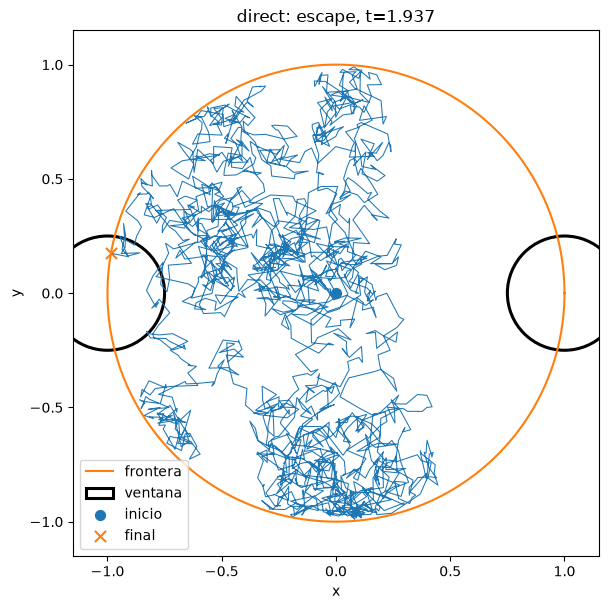

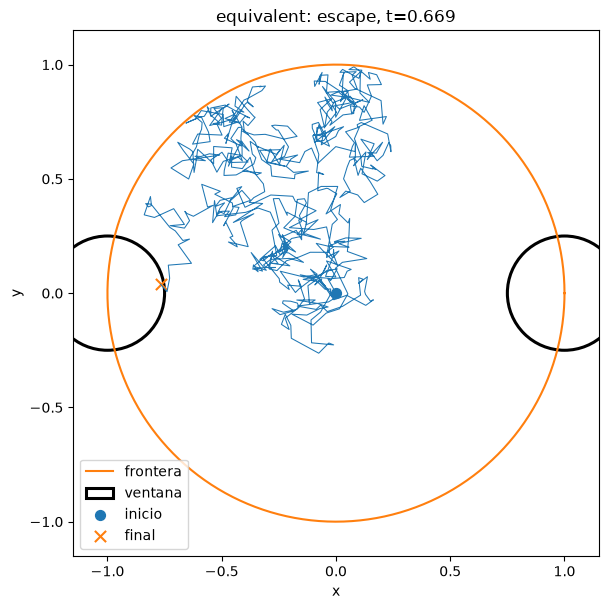

In [4]:
representative_seed = BASE_SEED
representative_dt = 1.0e-3
representative_max_steps = 1_000_000

representative_results = {}
for method, solver_type in (
    ("direct", NaiveNarrowEscape),
    ("equivalent", EquivalentNarrowEscape),
):
    motion = BrownianMotion(
        deposition_stride=100,
        delta_t=representative_dt,
        dimension=2,
        D=1.0,
        initial_position=np.zeros(2),
        seed=representative_seed,
    )
    solver = solver_type(motion, unit_disk(), absorbing_windows())
    representative_results[method] = solver.run(
        max_steps=representative_max_steps
    )

for method, result in representative_results.items():
    path = result.positions
    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    stride = max(1, len(path) // 8_000)
    ax.plot(path[::stride, 0], path[::stride, 1], linewidth=0.75)
    theta = np.linspace(0.0, 2.0 * np.pi, 700)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=1.5, label="frontera")
    for center in WINDOW_CENTERS:
        ax.add_patch(
            plt.Circle(
                center,
                WINDOW_RADIUS,
                fill=False,
                linewidth=2.2,
                label="ventana" if np.allclose(center, WINDOW_CENTERS[0]) else None,
            )
        )
    ax.scatter(*path[0], marker="o", s=50, label="inicio")
    ax.scatter(*path[-1], marker="x", s=65, label="final")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(
        f"{method}: {result.termination_reason}, "
        f"t={result.escape_time if result.escape_time is not None else np.nan:.4g}"
    )
    ax.legend()
    finish_figure(fig, f"representative_{method}")

In [5]:
if RUN_MODE == "full":
    DELTA_T_VALUES = np.array([4.0e-3, 2.0e-3, 1.0e-3, 5.0e-4])
    N_REPLICATES = 12
    MAX_STEPS = 600_000
else:
    DELTA_T_VALUES = np.geomspace(8.0e-3, 1.25e-4, 9)
    N_REPLICATES = 150
    MAX_STEPS = 4_000_000

if RUN_MODE == "load":
    if not SUMMARY_PATH.exists():
        raise FileNotFoundError(f"No existe el caché {SUMMARY_PATH}.")
    runs = pd.read_csv(SUMMARY_PATH)
elif REUSE_CACHE and SUMMARY_PATH.exists():
    runs = pd.read_csv(SUMMARY_PATH)
else:
    seed_sequences = np.random.SeedSequence(BASE_SEED).spawn(
        len(DELTA_T_VALUES) * N_REPLICATES
    )
    tasks = []
    cursor = 0
    for delta_t in DELTA_T_VALUES:
        for replicate in range(N_REPLICATES):
            seed = int(seed_sequences[cursor].generate_state(1)[0])
            cursor += 1
            # La misma semilla se utiliza para ambos métodos en cada pareja.
            for method in ("direct", "equivalent"):
                tasks.append(
                    EscapeCase(
                        method=method,
                        delta_t=float(delta_t),
                        seed=seed,
                        max_steps=MAX_STEPS,
                    )
                )

    records = Parallel(n_jobs=N_JOBS)(
        delayed(run_escape_case)(case) for case in tasks
    )
    runs = pd.DataFrame.from_records(records)
    SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    runs.to_csv(SUMMARY_PATH, index=False)

runs.head()

,method,delta_t,seed,escaped,escape_time,escape_index,attempted_steps,rejected_steps,rejection_fraction
0,direct,0.004,1117257062,True,0.710423,1,178,0,0.000000
1,equivalent,0.004,1117257062,True,0.600000,1,150,0,0.000000
2,direct,0.004,1739813875,True,0.224275,0,57,0,0.000000
3,equivalent,0.004,1739813875,True,0.148000,0,37,0,0.000000
4,direct,0.004,1419349886,True,2.595536,0,649,69,0.106317


In [6]:
def mean_ci(values: pd.Series, confidence: float = 0.95) -> tuple[float, float]:
    values = values.dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    mean = float(np.mean(values))
    if len(values) == 1:
        return mean, np.nan
    sem = stats.sem(values)
    half_width = float(
        stats.t.ppf((1.0 + confidence) / 2.0, len(values) - 1) * sem
    )
    return mean, half_width

rows = []
for (method, delta_t), group in runs.groupby(["method", "delta_t"]):
    mean_time, ci_time = mean_ci(group.loc[group["escaped"], "escape_time"])
    rows.append(
        {
            "method": method,
            "delta_t": delta_t,
            "n_runs": len(group),
            "escape_rate": group["escaped"].mean(),
            "mean_escape_time": mean_time,
            "ci95_escape_time": ci_time,
            "mean_rejection_fraction": group["rejection_fraction"].mean(),
        }
    )

summary = pd.DataFrame(rows).sort_values(["method", "delta_t"])
summary

,method,delta_t,n_runs,escape_rate,mean_escape_time,ci95_escape_time,mean_rejection_fraction
0,direct,0.0005,12,1.0,1.140299,0.537480,0.015902
1,direct,0.0010,12,1.0,1.194801,0.572092,0.026647
2,direct,0.0020,12,1.0,1.110857,0.647804,0.035250
3,direct,0.0040,12,1.0,1.290480,0.828128,0.048128
4,equivalent,0.0005,12,1.0,0.505833,0.242400,0.010491
5,equivalent,0.0010,12,1.0,0.707083,0.407947,0.021212
6,equivalent,0.0020,12,1.0,0.646833,0.626161,0.021863
7,equivalent,0.0040,12,1.0,0.740000,0.528695,0.038587


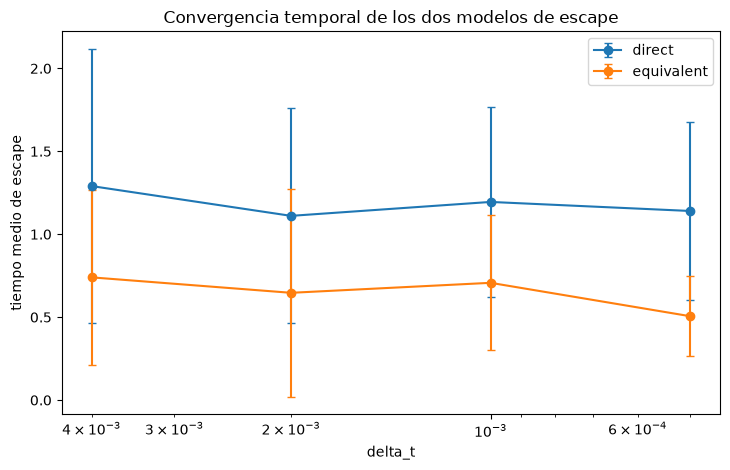

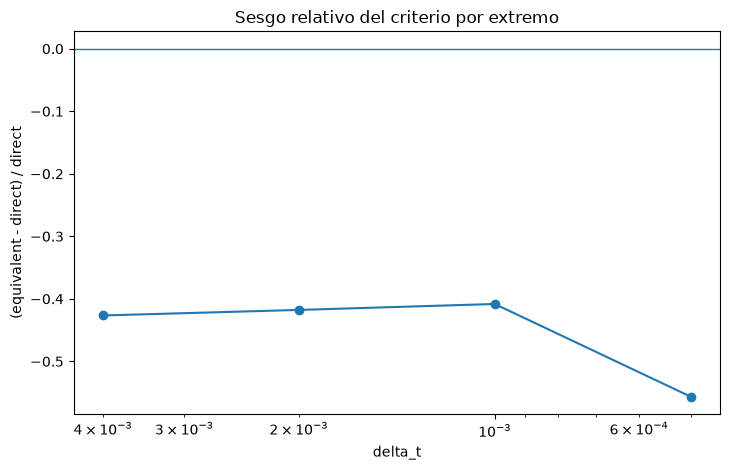

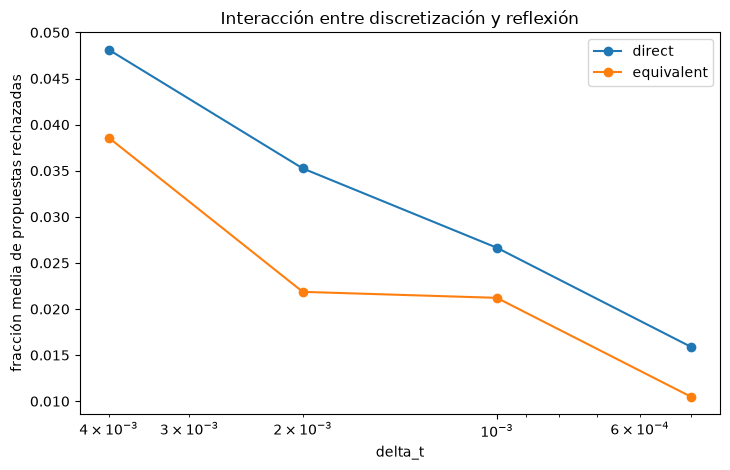

In [7]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for method, subset in summary.groupby("method"):
    ax.errorbar(
        subset["delta_t"],
        subset["mean_escape_time"],
        yerr=subset["ci95_escape_time"],
        marker="o",
        capsize=3,
        label=method,
    )
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("delta_t")
ax.set_ylabel("tiempo medio de escape")
ax.set_title("Convergencia temporal de los dos modelos de escape")
ax.legend()
finish_figure(fig, "mean_escape_time_vs_dt")

pivot = summary.pivot(index="delta_t", columns="method", values="mean_escape_time")
if {"direct", "equivalent"}.issubset(pivot.columns):
    relative_difference = (
        pivot["equivalent"] - pivot["direct"]
    ) / pivot["direct"]

    fig, ax = plt.subplots(figsize=(7.4, 4.8))
    ax.plot(relative_difference.index, relative_difference.values, marker="o")
    ax.axhline(0.0, linewidth=1.0)
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("delta_t")
    ax.set_ylabel("(equivalent - direct) / direct")
    ax.set_title("Sesgo relativo del criterio por extremo")
    finish_figure(fig, "relative_time_bias")

fig, ax = plt.subplots(figsize=(7.4, 4.8))
for method, subset in summary.groupby("method"):
    ax.plot(
        subset["delta_t"],
        subset["mean_rejection_fraction"],
        marker="o",
        label=method,
    )
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("delta_t")
ax.set_ylabel("fracción media de propuestas rechazadas")
ax.set_title("Interacción entre discretización y reflexión")
ax.legend()
finish_figure(fig, "rejection_fraction_vs_dt")